In [1]:
# ============================================================
# CELL 1: Environment Setup & Library Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ Pandas, NumPy, Matplotlib, and Seaborn imported successfully.")

✅ Pandas, NumPy, Matplotlib, and Seaborn imported successfully.


# Regression Track — Dataset Audit (A1)

**Problem statement:** predict the number of days taken to deliver a completed Olist order. Each record represents one delivered order, and the target variable is `delivery_days`. This audit reports the dataset shape, data types, missing-value counts, duplicate order identifiers, and target distribution before cleaning or feature selection.

In [2]:
# ============================================================
# CELL 2: Load All 9 Raw CSV Files & Merge Into Master DataFrame
# ============================================================
DATA_DIR = Path("olist_dataset") if Path("olist_dataset").exists() else Path("../olist_dataset")

print("⏳ Loading all 9 raw CSV files...")
orders       = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
order_items  = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
customers    = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
sellers      = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
products     = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
payments     = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews      = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
geolocation  = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
translations = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

print(f"  • orders:       {orders.shape[0]:,} rows × {orders.shape[1]} cols")
print(f"  • order_items:  {order_items.shape[0]:,} rows × {order_items.shape[1]} cols")
print(f"  • customers:    {customers.shape[0]:,} rows × {customers.shape[1]} cols")
print(f"  • sellers:      {sellers.shape[0]:,} rows × {sellers.shape[1]} cols")
print(f"  • products:     {products.shape[0]:,} rows × {products.shape[1]} cols")
print(f"  • payments:     {payments.shape[0]:,} rows × {payments.shape[1]} cols")
print(f"  • reviews:      {reviews.shape[0]:,} rows × {reviews.shape[1]} cols")
print(f"  • geolocation:  {geolocation.shape[0]:,} rows × {geolocation.shape[1]} cols")
print(f"  • translations: {translations.shape[0]:,} rows × {translations.shape[1]} cols")

# 1. Average GPS coordinates per zip code prefix (many raw rows → 1 row per zip)
geo_agg = geolocation.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "mean"),
    lng=("geolocation_lng", "mean")
).reset_index()

# 2. Filter for delivered orders with valid delivery timestamps
delivered = orders[orders["order_status"] == "delivered"].dropna(
    subset=["order_delivered_customer_date", "order_purchase_timestamp", "order_estimated_delivery_date"]
).copy()

# Parse datetime columns
for col in ["order_purchase_timestamp", "order_approved_at",
            "order_delivered_carrier_date", "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    delivered[col] = pd.to_datetime(delivered[col])

# 3. Compute Target Variable: delivery_days
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# 4. Aggregate order_items → 1 row per order
items_agg = order_items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum")
).reset_index()
first_item = (
    order_items.sort_values("order_item_id")
    .groupby("order_id").first().reset_index()
    [["order_id", "product_id", "seller_id"]]
)
items_agg = items_agg.merge(first_item, on="order_id", how="left")

# 5. Aggregate payments & reviews → 1 row per order
payments_agg = payments.groupby("order_id").agg(
    total_payment=("payment_value", "sum"),
    n_installments=("payment_installments", "max"),
    payment_type=("payment_type", "first")
).reset_index()
reviews_agg = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean")
).reset_index()

# 6. Translate product categories to English
products_tr = products.merge(translations, on="product_category_name", how="left")

# 7. Build Master Order-Level DataFrame
regression_df = delivered.merge(items_agg, on="order_id", how="inner")
regression_df = regression_df.merge(customers, on="customer_id", how="left")
regression_df = regression_df.merge(sellers, on="seller_id", how="left")
regression_df = regression_df.merge(products_tr, on="product_id", how="left")
regression_df = regression_df.merge(payments_agg, on="order_id", how="left")
regression_df = regression_df.merge(reviews_agg, on="order_id", how="left")

# 8. Attach real GPS coordinates via zip code prefix
regression_df = regression_df.merge(
    geo_agg.rename(columns={"geolocation_zip_code_prefix": "customer_zip_code_prefix",
                             "lat": "customer_lat", "lng": "customer_lng"}),
    on="customer_zip_code_prefix", how="left"
)
regression_df = regression_df.merge(
    geo_agg.rename(columns={"geolocation_zip_code_prefix": "seller_zip_code_prefix",
                             "lat": "seller_lat", "lng": "seller_lng"}),
    on="seller_zip_code_prefix", how="left"
)

# Integrity Checks
assert regression_df["order_id"].is_unique, "Each record must be one unique order."
assert regression_df["delivery_days"].notna().all(), "Target cannot have missing values."

print(f"\n✅ Master DataFrame ready!")
print(f"📦 Shape: {regression_df.shape[0]:,} rows × {regression_df.shape[1]} columns")
print(f"🧾 Unique Orders: {regression_df['order_id'].nunique():,}")
print(f"📍 Columns include real GPS: customer_lat/lng & seller_lat/lng")

⏳ Loading all 9 raw CSV files...
  • orders:       99,441 rows × 8 cols
  • order_items:  112,650 rows × 7 cols
  • customers:    99,441 rows × 5 cols
  • sellers:      3,095 rows × 4 cols
  • products:     32,951 rows × 9 cols
  • payments:     103,886 rows × 5 cols
  • reviews:      99,224 rows × 7 cols
  • geolocation:  1,000,163 rows × 5 cols
  • translations: 71 rows × 2 cols

✅ Master DataFrame ready!
📦 Shape: 96,470 rows × 38 columns
🧾 Unique Orders: 96,470
📍 Columns include real GPS: customer_lat/lng & seller_lat/lng


In [3]:
regression_df.shape

(96470, 38)

In [4]:
# ============================================================
# CELL 3: Criterion A1 — Feature Types & Missing Value Audit
# ============================================================
TARGET = "delivery_days"

audit_df = pd.DataFrame({
    "Column Name": regression_df.columns,
    "Data Type": regression_df.dtypes.astype(str),
    "Non-Null Count": regression_df.notna().sum(),
    "Missing Count": regression_df.isna().sum(),
    "Missing %": (regression_df.isna().sum() / len(regression_df) * 100).round(2)
}).reset_index(drop=True)

target_distribution = (
    pd.cut(
        regression_df[TARGET],
        bins=[-1, 1, 3, 7, 14, 30, np.inf],
        labels=["0–1 days", "2–3 days", "4–7 days", "8–14 days", "15–30 days", "31+ days"]
    )
    .value_counts(sort=False)
    .rename_axis("Delivery-Time Range")
    .reset_index(name="Order Count")
)
target_distribution["Percentage (%)"] = (
    target_distribution["Order Count"] / len(regression_df) * 100
).round(2)

print("=== 📋 DATASET AUDIT SUMMARY (Rubric A1) ===")
print(f"Total Rows:                 {regression_df.shape[0]:,}")
print(f"Total Columns:              {regression_df.shape[1]}")
print(f"Duplicate Order IDs:        {regression_df['order_id'].duplicated().sum():,}")
print(f"Missing Target Values:      {regression_df[TARGET].isna().sum():,}")
print(f"Columns with Missing Values: {(audit_df['Missing Count'] > 0).sum()} out of {len(regression_df.columns)}\n")

print("--- Column-Level Audit ---")
display(audit_df)

print("\n--- Binned Target Distribution (delivery_days) ---")
display(target_distribution)

=== 📋 DATASET AUDIT SUMMARY (Rubric A1) ===
Total Rows:                 96,470
Total Columns:              38
Duplicate Order IDs:        0
Missing Target Values:      0
Columns with Missing Values: 19 out of 38

--- Column-Level Audit ---


,Column Name,Data Type,Non-Null Count,Missing Count,Missing %
0,order_id,str,96470,0,0.000
1,customer_id,str,96470,0,0.000
2,order_status,str,96470,0,0.000
3,order_purchase_timestamp,datetime64[us],96470,0,0.000
4,order_approved_at,datetime64[us],96456,14,0.010
5,order_delivered_carrier_date,datetime64[us],96469,1,0.000
6,order_delivered_customer_date,datetime64[us],96470,0,0.000
7,order_estimated_delivery_date,datetime64[us],96470,0,0.000
8,delivery_days,float64,96470,0,0.000
9,n_items,int64,96470,0,0.000



--- Binned Target Distribution (delivery_days) ---


,Delivery-Time Range,Order Count,Percentage (%)
0,0–1 days,13,0.010
1,2–3 days,4740,4.910
2,4–7 days,21293,22.070
3,8–14 days,40212,41.680
4,15–30 days,25662,26.600
5,31+ days,4550,4.720


In [5]:
# ============================================================
# CELL 4: Criterion A1 — Target Variable Statistical Audit
# ============================================================
target = regression_df["delivery_days"]

print(f"=== 🎯 REGRESSION TARGET STATISTICAL METRICS: delivery_days ===")
print(f"Delivered Orders Audited : {len(regression_df):,} rows")
print(f"Count (Non-Null)         : {target.count():,}")
print(f"Mean Delivery Time       : {target.mean():.2f} days")
print(f"Standard Deviation       : {target.std():.2f} days")
print(f"Median (50th Percentile) : {target.median():.2f} days")
print(f"Minimum Delivery Time    : {target.min():.2f} days")
print(f"25th Percentile (Q1)     : {target.quantile(0.25):.2f} days")
print(f"75th Percentile (Q3)     : {target.quantile(0.75):.2f} days")
print(f"Maximum Delivery Time    : {target.max():.2f} days")
print(f"Interquartile Range (IQR): {target.quantile(0.75) - target.quantile(0.25):.2f} days")
print(f"Distribution Skewness    : {target.skew():.2f} (Positive / Right-Skewed)")
print(f"Distribution Kurtosis    : {target.kurt():.2f} (Leptokurtic / Heavy-Tailed)")

=== 🎯 REGRESSION TARGET STATISTICAL METRICS: delivery_days ===
Delivered Orders Audited : 96,470 rows
Count (Non-Null)         : 96,470
Mean Delivery Time       : 12.56 days
Standard Deviation       : 9.55 days
Median (50th Percentile) : 10.22 days
Minimum Delivery Time    : 0.53 days
25th Percentile (Q1)     : 6.77 days
75th Percentile (Q3)     : 15.72 days
Maximum Delivery Time    : 209.63 days
Interquartile Range (IQR): 8.95 days
Distribution Skewness    : 3.83 (Positive / Right-Skewed)
Distribution Kurtosis    : 39.32 (Leptokurtic / Heavy-Tailed)


## Section A — EDA Visualisations (Rubric A2 — 2 Marks, A3 — 1 Mark)

**Rubric A2 requires:**
1. Target variable distribution plot
2. Key feature distribution plots
3. Correlation heatmap (numeric features vs target)
4. ≥ 2 feature-vs-target scatter plots

**Rubric A3 requires:** Each plot accompanied by a Markdown insight commentary.

> **Design Choice:** For the 9.9% of orders containing multiple line items,
> we represent the order using its first item's product dimensions and seller
> location. Aggregated order-level features (n_items, total_price, total_freight)
> are summed across all items.
> **Design Choice:** For the 2.3% of orders with mixed payment methods,
> we capture the primary payment type (first recorded method).
> The total payment value is always fully aggregated across all payment rows.


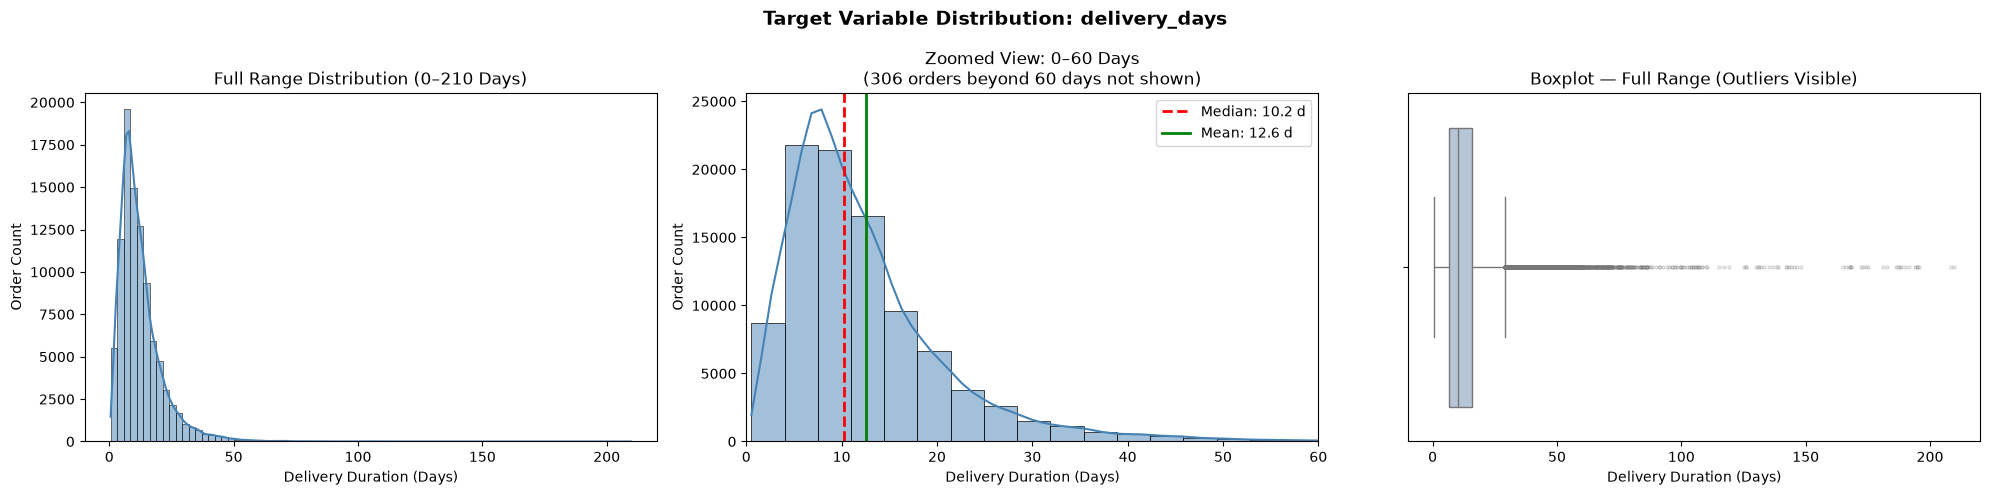

In [6]:
# ============================================================
# CELL 5: A2 — Target Variable Distribution (delivery_days)
# ============================================================
target = regression_df['delivery_days']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Target Variable Distribution: delivery_days", fontsize=14, fontweight='bold')

# Panel 1: Full range histogram
sns.histplot(target, bins=80, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title("Full Range Distribution (0–210 Days)")
axes[0].set_xlabel("Delivery Duration (Days)")
axes[0].set_ylabel("Order Count")

# Panel 2: Zoomed 0–60 days (clearly labelled)
beyond_60 = (target > 60).sum()
sns.histplot(target, bins=60, kde=True, color='steelblue', ax=axes[1])
axes[1].set_xlim(0, 60)
axes[1].set_title(f"Zoomed View: 0–60 Days\n({beyond_60:,} orders beyond 60 days not shown)")
axes[1].set_xlabel("Delivery Duration (Days)")
axes[1].set_ylabel("Order Count")
axes[1].axvline(target.median(), color='red',   linestyle='--', linewidth=2, label=f'Median: {target.median():.1f} d')
axes[1].axvline(target.mean(),   color='green', linewidth=2,              label=f'Mean: {target.mean():.1f} d')
axes[1].legend()

# Panel 3: Boxplot — Full range
sns.boxplot(x=target, ax=axes[2], color='lightsteelblue',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[2].set_title("Boxplot — Full Range (Outliers Visible)")
axes[2].set_xlabel("Delivery Duration (Days)")

plt.tight_layout()
plt.show()

